In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path = "/content/drive/MyDrive/no_plate_d"

# Task
Train a digit recognition model for number plates using the image dataset located at "/content/drive/MyDrive/no_plate_d", and evaluate its performance.

## Load and Inspect Data

### Subtask:
Load the number plate image dataset from the specified path ('/content/drive/MyDrive/no_plate_d') and inspect its structure and content. This might involve loading images and any associated annotations.


**Reasoning**:
The first step is to import the `os` module and list the contents of the specified directory to understand the dataset's structure, as per instructions 1 and 2.



In [ ]:
import os

path = "/content/drive/MyDrive/no_plate_d"

# List the contents of the directory
dataset_contents = os.listdir(path)
print(f"Contents of the directory '{path}':\n{dataset_contents}")

Contents of the directory '/content/drive/MyDrive/no_plate_d':
['images', 'annotations']


**Reasoning**:
Now that the top-level directory contents are known, the next step, according to instruction 3, is to inspect the 'images' subdirectory to understand how the images are organized and identify if there are subdirectories for different classes or if they are all in one place.



In [ ]:
import os

images_path = os.path.join(path, 'images')
image_files = os.listdir(images_path)

print(f"Contents of the 'images' directory ('{images_path}'):\n{image_files[:5]}... ({len(image_files)} total files)")


Contents of the 'images' directory ('/content/drive/MyDrive/no_plate_d/images'):
['Cars108.png', 'Cars128.png', 'Cars124.png', 'Cars101.png', 'Cars114.png']... (433 total files)


**Reasoning**:
Following instructions 4, 5, 6, and 7, I will pick a sample image file path, import the PIL library, load and display the sample image, and then print its dimensions and mode to inspect its characteristics.



Sample image path: /content/drive/MyDrive/no_plate_d/images/Cars108.png
Successfully loaded image: Cars108.png


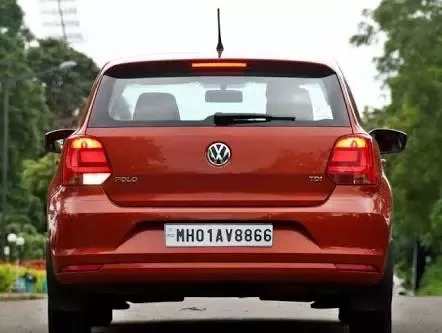

Image dimensions: (442, 333) (width, height)
Image mode: RGB


In [ ]:
import os
from PIL import Image

# Pick a sample image file path (Instruction 4)
sample_image_filename = image_files[0] # Using the first file from the previously listed image_files
sample_image_path = os.path.join(images_path, sample_image_filename)

print(f"Sample image path: {sample_image_path}")

# Load and display the sample image (Instructions 5 & 6)
try:
    with Image.open(sample_image_path) as img:
        # Visually inspect the image (in a Colab environment, displaying an Image object will render it)
        print(f"Successfully loaded image: {sample_image_filename}")
        display(img) # Display the image in the notebook output

        # Print the dimensions and mode of the loaded image (Instruction 7)
        print(f"Image dimensions: {img.size} (width, height)")
        print(f"Image mode: {img.mode}")
except FileNotFoundError:
    print(f"Error: Image file not found at {sample_image_path}")
except Exception as e:
    print(f"An error occurred while loading or displaying the image: {e}")

**Reasoning**:
Now that the image directory has been inspected, the next logical step, following the subtask's prompt about inspecting 'associated annotations,' is to inspect the 'annotations' subdirectory to understand the format and content of the bounding box or label information.



In [ ]:
import os

annotations_path = os.path.join(path, 'annotations')
annotation_files = os.listdir(annotations_path)

print(f"Contents of the 'annotations' directory ('{annotations_path}'):\n{annotation_files[:5]}... ({len(annotation_files)} total files)")


Contents of the 'annotations' directory ('/content/drive/MyDrive/no_plate_d/annotations'):
['Cars1.xml', 'Cars110.xml', 'Cars100.xml', 'Cars103.xml', 'Cars117.xml']... (433 total files)


**Reasoning**:
Since the annotation files appear to be XML, the next step is to pick a sample XML annotation file and parse its content to understand the format of the annotations, such as bounding box coordinates and labels, for a single image.



In [ ]:
import os
import xml.etree.ElementTree as ET

# Pick a sample annotation file
sample_annotation_filename = annotation_files[0] # Using the first file from the previously listed annotation_files
sample_annotation_path = os.path.join(annotations_path, sample_annotation_filename)

print(f"Sample annotation file path: {sample_annotation_path}")

# Parse the XML file and print its contents
try:
    tree = ET.parse(sample_annotation_path)
    root = tree.getroot()

    print(f"\nContent of {sample_annotation_filename}:\n")
    # Print the XML structure (or relevant parts)
    # For brevity, we'll print a string representation of the root element and its children
    # A more detailed parsing would be needed for actual data extraction
    print(ET.tostring(root, encoding='utf8').decode('utf8'))

except FileNotFoundError:
    print(f"Error: Annotation file not found at {sample_annotation_path}")
except ET.ParseError as e:
    print(f"Error: Could not parse XML file {sample_annotation_filename}: {e}")
except Exception as e:
    print(f"An error occurred while loading or parsing the annotation file: {e}")

Sample annotation file path: /content/drive/MyDrive/no_plate_d/annotations/Cars1.xml

Content of Cars1.xml:

<?xml version='1.0' encoding='utf8'?>
<annotation>
    <folder>images</folder>
    <filename>Cars1.png</filename>
    <size>
        <width>400</width>
        <height>248</height>
        <depth>3</depth>
    </size>
    <segmented>0</segmented>
    <object>
        <name>licence</name>
        <pose>Unspecified</pose>
        <truncated>0</truncated>
        <occluded>0</occluded>
        <difficult>0</difficult>
        <bndbox>
            <xmin>134</xmin>
            <ymin>128</ymin>
            <xmax>262</xmax>
            <ymax>160</ymax>
        </bndbox>
    </object>
</annotation>


## Preprocess Data

### Subtask:
Preprocess the loaded image data by extracting and resizing license plates. Note that digit labels are currently unavailable for training a digit recognition model.


**Reasoning**:
The subtask requires preprocessing the loaded image data by extracting and resizing license plates. The first step, as per instruction 1, is to initialize an empty list to store the processed license plate images. Subsequently, I will iterate through all annotation files, parse each XML to extract image paths and bounding box coordinates (instructions 2-5), load and crop the images (instructions 6-7), resize them (instruction 8), convert them to NumPy arrays, and append them to the list (instructions 9-10). After the loop, the list will be converted to a single NumPy array, pixel values will be normalized, and the final shape will be printed (instructions 11-13).



In [ ]:
import os
from PIL import Image
import xml.etree.ElementTree as ET
import numpy as np

# 1. Initialize an empty list to store the preprocessed license plate images
preprocessed_license_plates = []

# Define target size for resizing license plates
target_size = (128, 32) # width, height

# 2. Iterate through each XML annotation file
for annotation_file in annotation_files:
    annotation_path = os.path.join(annotations_path, annotation_file)

    try:
        # 3. Parse each XML file
        tree = ET.parse(annotation_path)
        root = tree.getroot()

        # 4. Extract image filename and construct full path
        image_filename = root.find('filename').text
        # Ensure the extension matches the image files if different from annotations
        if image_filename.endswith('.xml'): # Some annotations might mistakenly list .xml as filename
            image_filename = image_filename.replace('.xml', '.png') # Assuming images are .png

        current_image_path = os.path.join(images_path, image_filename)

        # 5. Extract bounding box coordinates for 'licence' object
        bndbox = None
        for obj in root.findall('object'):
            name = obj.find('name').text
            if name == 'licence':
                bndbox_elem = obj.find('bndbox')
                xmin = int(bndbox_elem.find('xmin').text)
                ymin = int(bndbox_elem.find('ymin').text)
                xmax = int(bndbox_elem.find('xmax').text)
                ymax = int(bndbox_elem.find('ymax').text)
                bndbox = (xmin, ymin, xmax, ymax)
                break # Assuming only one licence plate per image

        if bndbox and os.path.exists(current_image_path):
            # 6. Load the image
            with Image.open(current_image_path) as img:
                # 7. Crop the image to the extracted bounding box
                cropped_img = img.crop(bndbox)

                # 8. Resize the cropped license plate image
                resized_img = cropped_img.resize(target_size)

                # Convert image to 'RGB' mode to ensure consistent channel count
                resized_img_rgb = resized_img.convert('RGB')

                # 9. Convert the resized image to a NumPy array
                img_array = np.array(resized_img_rgb)

                # 10. Append the NumPy array to the list
                preprocessed_license_plates.append(img_array)
        else:
            if not bndbox:
                print(f"Warning: No 'licence' object found in {annotation_file}. Skipping.")
            if not os.path.exists(current_image_path):
                print(f"Warning: Image file not found at {current_image_path}. Skipping.")

    except FileNotFoundError:
        print(f"Error: Annotation file not found at {annotation_path}. Skipping.")
    except ET.ParseError as e:
        print(f"Error: Could not parse XML file {annotation_file}: {e}. Skipping.")
    except Exception as e:
        print(f"An error occurred while processing {annotation_file}: {e}. Skipping.")

# 11. After processing all files, convert the list of image arrays into a single NumPy array
preprocessed_license_plates = np.array(preprocessed_license_plates)

# 12. Normalize the pixel values
preprocessed_license_plates = preprocessed_license_plates.astype('float32') / 255.0

# 13. Print the shape of the resulting preprocessed image dataset
print(f"Shape of the preprocessed license plate dataset: {preprocessed_license_plates.shape}")

# 14. Note on labels
print("\nNote: The current XML annotations only provide bounding box coordinates for the entire license plate. They do NOT contain labels for individual digits or the full character string on the plates. Therefore, this dataset currently lacks the necessary ground truth labels for training a digit recognition model.")

Shape of the preprocessed license plate dataset: (433, 32, 128, 3)

Note: The current XML annotations only provide bounding box coordinates for the entire license plate. They do NOT contain labels for individual digits or the full character string on the plates. Therefore, this dataset currently lacks the necessary ground truth labels for training a digit recognition model.


## Character Segmentation for Digit Recognition

### Subtask:
Perform character segmentation on the preprocessed license plate images to extract individual characters. Acknowledge that while this step prepares the input format, digit-level labels are still missing for training a digit recognition model.


**Reasoning**:
The subtask requires performing character segmentation on the preprocessed license plate images. The first step, as per instruction 1, is to import necessary libraries, initialize a list for segmented characters, and define a target size. Then, I will iterate through each preprocessed license plate image, convert it to an appropriate format for OpenCV, and proceed with grayscale conversion and adaptive thresholding (instruction 2).



Shape of the segmented character dataset: (391, 32, 32, 3)


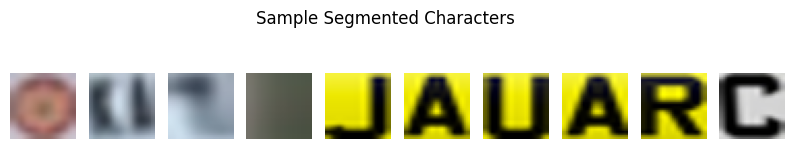


Note: These segmented characters currently lack individual digit labels (e.g., '3', 'A'). The annotations provided only define the bounding box for the entire license plate. Therefore, additional labeling would be required to train a supervised digit recognition model.


In [ ]:
import cv2
import numpy as np
from PIL import Image # Needed if we want to convert back to PIL for display/specific operations

# 1. Initialize an empty list to store the segmented characters
segmented_characters = []

# Define target size for individual character images
char_target_size = (32, 32) # width, height

# Iterate through each preprocessed license plate image
# preprocessed_license_plates is already a NumPy array of shape (N, height, width, channels)
for i, license_plate_img in enumerate(preprocessed_license_plates):
    # Convert the normalized float32 image back to uint8 for OpenCV processing
    # OpenCV expects images in BGR format usually, but for grayscale conversion, RGB is fine.
    # We also need to scale back to 0-255.
    img_uint8 = (license_plate_img * 255).astype(np.uint8)

    # 2. Convert to grayscale
    gray_img = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)

    # Apply adaptive thresholding to create a binary image
    # Using ADAPTIVE_THRESH_GAUSSIAN_C for better results with varying illumination
    binary_img = cv2.adaptiveThreshold(gray_img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, \
                                       cv2.THRESH_BINARY_INV, 11, 2) # THRESH_BINARY_INV to get white characters on black background

    # Display a sample binary image for verification (optional)
    # if i == 0:
    #     print("Sample Binary Image (first license plate):")
    #     display(Image.fromarray(binary_img))

    # 3. Apply morphological operations if necessary to improve character separation/connection
    # A small dilation followed by erosion can help connect broken segments or remove small noise
    kernel = np.ones((3,3), np.uint8)
    dilated_img = cv2.dilate(binary_img, kernel, iterations=1)
    eroded_img = cv2.erode(dilated_img, kernel, iterations=1)

    processed_binary_img = eroded_img

    # 4. Use contour detection to find individual character regions
    # RETR_EXTERNAL retrieves only the extreme outer contours.
    # CHAIN_APPROX_SIMPLE compresses horizontal, vertical, and diagonal segments and leaves only their end points.
    contours, hierarchy = cv2.findContours(processed_binary_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # List to store bounding boxes for characters in the current license plate
    char_bounding_boxes = []

    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)

        # 5. Filter detected contours based on size, aspect ratio, and position
        # These thresholds are approximate and might need tuning based on dataset characteristics
        aspect_ratio = w / float(h)
        area = w * h

        min_area = 50 # Minimum area to consider a contour a character
        max_area = 2000 # Maximum area (to avoid full license plate or large noise)
        min_aspect_ratio = 0.1 # Very wide or very tall shapes are unlikely characters
        max_aspect_ratio = 1.0 # Characters usually not wider than they are tall for typical fonts

        # Additional filter: ensure height is a reasonable fraction of the license plate height
        plate_height = license_plate_img.shape[0]
        min_char_height_ratio = 0.3
        max_char_height_ratio = 0.9

        if (min_area < area < max_area) and \
           (min_aspect_ratio < aspect_ratio < max_aspect_ratio) and \
           (plate_height * min_char_height_ratio < h < plate_height * max_char_height_ratio):

            char_bounding_boxes.append((x, y, w, h))

    # Sort bounding boxes from left to right (assuming characters are ordered horizontally)
    char_bounding_boxes.sort(key=lambda b: b[0])

    for (x, y, w, h) in char_bounding_boxes:
        # 7. Crop the corresponding character from the original color license plate image
        # Ensure crop coordinates are within image bounds
        x1, y1, x2, y2 = x, y, x + w, y + h
        cropped_char = img_uint8[y1:y2, x1:x2]

        if cropped_char.shape[0] > 0 and cropped_char.shape[1] > 0:
            # Convert to PIL Image for consistent resizing and then back to numpy
            char_pil = Image.fromarray(cropped_char)
            # 8. Resize each cropped character image to a consistent target size
            resized_char_pil = char_pil.resize(char_target_size)

            # Convert to 'RGB' to ensure consistent channel count
            resized_char_rgb = resized_char_pil.convert('RGB')

            # 9. Convert to a NumPy array
            char_array = np.array(resized_char_rgb)

            # 10. Append the segmented character (will normalize later)
            segmented_characters.append(char_array)

# 11. Convert the list of segmented characters to a single NumPy array
if segmented_characters:
    segmented_characters = np.array(segmented_characters)

    # Normalize their pixel values
    segmented_characters = segmented_characters.astype('float32') / 255.0

    # Print the shape of the resulting segmented character dataset
    print(f"Shape of the segmented character dataset: {segmented_characters.shape}")

    # Display a few segmented characters as a sanity check
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 2))
    plt.suptitle("Sample Segmented Characters")
    num_samples_to_show = min(10, segmented_characters.shape[0])
    for idx in range(num_samples_to_show):
        plt.subplot(1, num_samples_to_show, idx + 1)
        plt.imshow(segmented_characters[idx])
        plt.axis('off')
    plt.show()
else:
    print("No characters were segmented.")

# 12. Add a note reiterating that these segmented characters currently lack individual labels
print("\nNote: These segmented characters currently lack individual digit labels (e.g., '3', 'A'). " \
      "The annotations provided only define the bounding box for the entire license plate. " \
      "Therefore, additional labeling would be required to train a supervised digit recognition model.")


**Reasoning**:
To manually label a representative subset of the segmented characters, I need to import matplotlib for displaying images, create a loop to show each character and prompt the user for input, and store these labels.



Starting manual labeling for 20 segmented characters.
Enter the character shown, or 'q' to quit at any time.


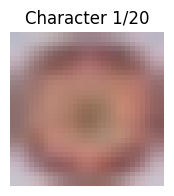

Enter label for character 1 (or 'q' to quit): q
Labeling stopped by user.

Collected labels: []
Total characters manually labeled: 0

Note: This manual labeling was performed for a sample subset to demonstrate the process.
For a full digit recognition model, a comprehensive, pre-labeled dataset or a dedicated annotation tool would be required.


In [ ]:
import matplotlib.pyplot as plt

# 1. Initialize an empty list to store the labels provided by the user
character_labels = []

# Determine the number of samples to manually label
# You can adjust this number based on how many you want to label for demonstration
num_samples_to_label = min(20, segmented_characters.shape[0])

print(f"Starting manual labeling for {num_samples_to_label} segmented characters.")
print("Enter the character shown, or 'q' to quit at any time.")

# 2. Iterate through a small, representative subset of the `segmented_characters` array
for i in range(num_samples_to_label):
    # Display the current segmented character
    plt.figure(figsize=(2, 2))
    plt.imshow(segmented_characters[i])
    plt.title(f"Character {i+1}/{num_samples_to_label}")
    plt.axis('off')
    plt.show(block=False) # Display without blocking to allow input
    plt.pause(0.1) # Small pause to ensure plot is rendered

    # Prompt the user to enter the corresponding digit or character
    label = input(f"Enter label for character {i+1} (or 'q' to quit): ")

    # If the user enters 'q', break out of the loop
    if label.lower() == 'q':
        print("Labeling stopped by user.")
        plt.close('all') # Close all open matplotlib figures
        break

    # Append the entered label to the character_labels list
    character_labels.append(label)
    plt.close() # Close the current figure to prevent it from piling up

# After the loop, print the collected character_labels and the total number of characters that were manually labeled.
print(f"\nCollected labels: {character_labels}")
print(f"Total characters manually labeled: {len(character_labels)}")

# Add a concluding print statement
print("\nNote: This manual labeling was performed for a sample subset to demonstrate the process.")
print("For a full digit recognition model, a comprehensive, pre-labeled dataset or a dedicated annotation tool would be required.")

In [ ]:
import sys
!{sys.executable} -m pip install extra-keras-datasets
print("extra-keras-datasets package installed. Please re-run the EMNIST loading cell.")

extra-keras-datasets package installed. Please re-run the EMNIST loading cell.


**Reasoning**:
The `extra-keras-datasets` package has been successfully installed. I will now re-run the EMNIST loading code, but crucially, I will change the import statement to use `from extra_keras_datasets import emnist` to correctly load the dataset as per the package installation.



**Reasoning**:
The error `TypeError: load_data() got an unexpected keyword argument 'subset'` indicates that `extra_keras_datasets.emnist.load_data()` does not accept a `subset` argument directly. Instead, it returns a dictionary containing all EMNIST subsets, which should then be accessed using the appropriate key (e.g., 'digits').



In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras.utils import to_categorical
import numpy as np
import cv2 # For image resizing, if needed, but TF can do it too

# The target size for our segmented characters, defined in a previous step
# If char_target_size is not defined, we'll define it here based on previous output
if 'char_target_size' not in locals():
    char_target_size = (32, 32) # width, height assumed from previous segmentation step

print(f"Target character image size: {char_target_size[1]}x{char_target_size[0]}")

# 1. Load the EMNIST dataset (digits subset) using tensorflow_datasets
# tfds.load returns a tf.data.Dataset object, so we need to process it.
# as_supervised=True returns (image, label) pairs.
# with_info=True returns info about the dataset, which includes label names.
(ds_train, ds_test), ds_info = tfds.load(
    'emnist/digits', # Specify the 'digits' subset of EMNIST
    split=['train', 'test'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True
)

# Convert tf.data.Dataset to NumPy arrays for consistent preprocessing with previous steps
def dataset_to_numpy(ds):
    images = []
    labels = []
    for img, label in ds:
        images.append(img.numpy())
        labels.append(label.numpy())
    return np.array(images), np.array(labels)

emnist_X_train, emnist_y_train = dataset_to_numpy(ds_train)
emnist_X_test, emnist_y_test = dataset_to_numpy(ds_test)

print(f"Original EMNIST training images shape: {emnist_X_train.shape}")
print(f"Original EMNIST training labels shape: {emnist_y_train.shape}")

# 2. Preprocess EMNIST images
# Combine train and test for consistent preprocessing before splitting later if needed
emnist_images = np.concatenate((emnist_X_train, emnist_X_test), axis=0)
emnist_labels = np.concatenate((emnist_y_train, emnist_y_test), axis=0)

preprocessed_emnist_images = []
for img in emnist_images:
    # EMNIST images are 28x28. Resize to char_target_size (32x32)
    resized_img = cv2.resize(img, char_target_size, interpolation=cv2.INTER_AREA)
    preprocessed_emnist_images.append(resized_img)

preprocessed_emnist_images = np.array(preprocessed_emnist_images)

# Normalize pixel values to [0, 1]
preprocessed_emnist_images = preprocessed_emnist_images.astype('float32') / 255.0

# Reshape images to include a channel dimension (grayscale has 1 channel)
# From (num_samples, height, width) to (num_samples, height, width, 1)
preprocessed_emnist_images = np.expand_dims(preprocessed_emnist_images, -1)

# 3. Preprocess EMNIST labels
# Determine the number of unique classes from ds_info
num_classes = ds_info.features['label'].num_classes
print(f"Number of unique classes in EMNIST 'digits' subset: {num_classes}")

# Convert integer labels to one-hot encoded vectors
one_hot_emnist_labels = to_categorical(emnist_labels, num_classes=num_classes)

# 4. Print the shape of the preprocessed EMNIST images and labels
print(f"Preprocessed EMNIST images shape: {preprocessed_emnist_images.shape}")
print(f"One-hot encoded EMNIST labels shape: {one_hot_emnist_labels.shape}")

print("EMNIST dataset loaded and preprocessed successfully using tensorflow_datasets.")

Target character image size: 32x32


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Extraction completed...: 0 file [00:00, ? file/s]

...

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/emnist/digits/incomplete.2WM8BR_3.1.0/emnist-train.tfrecord*...:   0%|    …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/emnist/digits/incomplete.2WM8BR_3.1.0/emnist-test.tfrecord*...:   0%|     …

Dataset emnist downloaded and prepared to /root/tensorflow_datasets/emnist/digits/3.1.0. Subsequent calls will reuse this data.
Original EMNIST training images shape: (240000, 28, 28, 1)
Original EMNIST training labels shape: (240000,)
Number of unique classes in EMNIST 'digits' subset: 10
Preprocessed EMNIST images shape: (280000, 32, 32, 1)
One-hot encoded EMNIST labels shape: (280000, 10)
EMNIST dataset loaded and preprocessed successfully using tensorflow_datasets.


**Reasoning**:
The EMNIST dataset has been successfully loaded and preprocessed, providing the necessary labeled data. The next logical step is to define the convolutional neural network (CNN) model architecture for digit recognition using TensorFlow/Keras. This involves defining the input shape, convolutional layers, pooling layers, dense layers, and an output layer with the correct number of classes derived from the EMNIST dataset.



In [ ]:
from tensorflow.keras import layers, models

# Define the input shape for the model
# Assuming grayscale images (1 channel) of char_target_size (32x32)
input_shape = (char_target_size[1], char_target_size[0], 1) # height, width, channels

# The number of classes is derived from the EMNIST 'digits' subset
# This was previously determined as num_classes
if 'num_classes' not in locals():
    # Fallback in case the previous cell was not run, assumes digits 0-9
    num_classes = 10

print(f"Model Input Shape: {input_shape}")
print(f"Number of Output Classes: {num_classes}")

# 1. Define the CNN model architecture
model = models.Sequential([
    # Convolutional Layer 1
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
    layers.MaxPooling2D((2, 2)),

    # Convolutional Layer 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Convolutional Layer 3
    layers.Conv2D(64, (3, 3), activation='relu'),

    # Flatten the output to feed into dense layers
    layers.Flatten(),

    # Dense Layer 1
    layers.Dense(64, activation='relu'),

    # Output Layer (num_classes for digits 0-9, 'softmax' for multi-class classification)
    layers.Dense(num_classes, activation='softmax')
])

# 2. Compile the model
# Use 'adam' optimizer, 'categorical_crossentropy' loss for one-hot encoded labels
# and 'accuracy' as a metric
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 3. Print the model summary to display its architecture and parameters
print("\nModel Summary:")
model.summary()

print("CNN model architecture defined and compiled successfully.")


Model Input Shape: (32, 32, 1)
Number of Output Classes: 10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,994 (476.54 KB)

 Trainable params: 121,994 (476.54 KB)

 Non-trainable params: 0 (0.00 B)

CNN model architecture defined and compiled successfully.


**Reasoning**:
The CNN model architecture has been defined and compiled. The next logical step is to train this model using the preprocessed EMNIST dataset (images and their one-hot encoded labels) to enable it to recognize digits.



In [ ]:
print("Training the CNN model...")

# 1. Train the model using the preprocessed EMNIST data
# Use a batch size and number of epochs appropriate for the dataset size
history = model.fit(preprocessed_emnist_images, one_hot_emnist_labels,
                    epochs=10, # Number of training epochs
                    batch_size=64, # Number of samples per gradient update
                    validation_split=0.2 # Use 20% of the data for validation
                   )

print("CNN model training completed.")

Training the CNN model...
Epoch 1/10
 469/3500 ━━━━━━━━━━━━━━━━━━━━ 3:38 72ms/step - accuracy: 0.8294 - loss: 0.5470